In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Spécifie le chemin du fichier dans Google Drive
file_path = '/content/drive/My Drive/Projet/df_file.csv'


Mounted at /content/drive


In [ ]:
# Charger le fichier
import pandas as pd
data = pd.read_csv(file_path)

# Afficher le nombre total de documents dans le dataset
print(f"Nombre total de documents dans le dataset : {len(data)}")

# Aperçu du dataset
print("Aperçu du dataset :")

print(data.head())

print("Distribution des classes :", data['Label'].value_counts())

# Vérifier les valeurs manquantes
print("\nValeurs manquantes :")
print(data.isnull().sum())





Nombre total de documents dans le dataset : 2225
Aperçu du dataset :
                                                Text  Label
0  Budget to set scene for election\n \n Gordon B...      0
1  Army chiefs in regiments decision\n \n Militar...      0
2  Howard denies split over ID cards\n \n Michael...      0
3  Observers to monitor UK election\n \n Minister...      0
4  Kilroy names election seat target\n \n Ex-chat...      0
Distribution des classes : Label
1    511
4    510
0    417
2    401
3    386
Name: count, dtype: int64

Valeurs manquantes :
Text     0
Label    0
dtype: int64


In [ ]:
# Nettoyage des textes
import re

def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Supprime les caractères spéciaux et les chiffres
    text = text.lower()  # Met tout en minuscule
    text = re.sub(r"\s+", " ", text).strip()  # Supprime les espaces multiples
    return text

# Appliquer le nettoyage
data['Text'] = data['Text'].apply(clean_text)

# Sauvegarder le fichier nettoyé dans un nouveau CSV
data.to_csv('/content/cleaned_data.csv', index=False)

# Téléchargement du fichier nettoyé
from google.colab import files
files.download('/content/cleaned_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


# Séparer les données en ensembles d'entraînement et de test
X = data['Text']
y = data['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Tokenisation et padding
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
vocab_size = len(tokenizer.word_index) + 1
max_len = 150  # Limite réduite pour améliorer les performances

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Exemple d'un texte avant et après prétraitement
example_text = X_train.iloc[0]
print("Texte original :", example_text)

# Après nettoyage
cleaned_text = clean_text(example_text)
print("Texte nettoyé :", cleaned_text)

# Après tokenisation
example_seq = tokenizer.texts_to_sequences([cleaned_text])
print("Texte tokenisé :", example_seq)

# Après padding
example_padded = pad_sequences(example_seq, maxlen=max_len, padding='post')
print("Texte après padding :", example_padded[0])





Texte original : blair buys copies of new band aid prime minister tony blair purchased two copies of the charity single band aid in edinburgh on friday staff were surprised when the prime minister walked into hmv at gmt accompanied by aides and local police when mr blair came in unannounced we were all pretty gobsmacked said hmv manager clive smith our customer helper approached him it was only then we realised he wanted to buy copies of the band aid single rather than the latest eminem album predicted charttopper do they know its christmas is expected to sell at least copies by the time the new chart is announced on sunday however the new version of the single is not going to be released in the us despite being sold in many countries around the world us record shops are stocking an import version of do they know its christmas which is said to be selling very well in los angeles and new york the original track was released in the us and reached number in the singles chart british stars

In [ ]:
# Charger les embeddings GloVe
embedding_dim = 100  # Dimension des vecteurs GloVe
embedding_index = {}
with open('/content/drive/My Drive/Projet/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

# Créer la matrice d'embedding
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# Afficher un aperçu de la matrice d'embedding
print("Dimensions de la matrice d'embedding :", embedding_matrix.shape)

# Afficher quelques vecteurs d'embedding (par exemple, les 5 premiers)
print("Exemple de vecteurs d'embedding :")
for i in range(5):  # Affiche les 5 premiers vecteurs
    print(f"Mot {i + 1}: {embedding_matrix[i]}")

Dimensions de la matrice d'embedding : (28480, 100)
Exemple de vecteurs d'embedding :
Mot 1: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
Mot 2: [-0.038194   -0.24487001  0.72812003 -0.39961001  0.083172    0.043953
 -0.39140999  0.3344     -0.57545     0.087459    0.28786999 -0.06731
  0.30906001 -0.26383999 -0.13231    -0.20757     0.33395001 -0.33848
 -0.31742999 -0.48335999  0.1464     -0.37303999  0.34577     0.052041
  0.44946    -0.46970999  0.02628    -0.54154998 -0.15518001 -0.14106999
 -0.039722    0.28277001  0.14393     0.23464    -0.31020999  0.086173
  0.20397     0.52623999  0.17163999 -0.082378   -0.71787    -0.41531
  0.20334999 -0.12763     0.41367     0.55186999  0.57907999 -0.33476999
 -0.36559001 -0.54856998 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
import numpy as np

# Construction du modèle
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False,name="GloVe_Embedding"),
    LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(64, activation='relu', kernel_regularizer='l2'),
    Dropout(0.4),
    Dense(5, activation='softmax')  # 5 classes
])

# Initialisation explicite avec une entrée fictive
dummy_input = np.random.randint(0, vocab_size, size=(1, max_len))  # Une entrée fictive
model(dummy_input)  # Forcer la construction des couches

# Compilation
model.compile(
    optimizer=RMSprop(learning_rate=0.001),  # RMSprop avec un taux d'apprentissage réduit
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Résumé du modèle
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ GloVe_Embedding (Embedding)          │ (1, 150, 100)               │       2,848,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (1, 150, 128)               │         117,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (1, 64)                     │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (1, 64)                     │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (1, 64)                     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (1, 5)                      │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,019,141 (11.52 MB)

 Trainable params: 171,141 (668.52 KB)

 Non-trainable params: 2,848,000 (10.86 MB)

In [ ]:
# Entraînement
history = model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_test_padded, y_test),
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 23s 331ms/step - accuracy: 0.2968 - loss: 2.0966 - val_accuracy: 0.6202 - val_loss: 1.4823
Epoch 2/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.5652 - loss: 1.5120 - val_accuracy: 0.7888 - val_loss: 0.9742
Epoch 3/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 350ms/step - accuracy: 0.6577 - loss: 1.2511 - val_accuracy: 0.7371 - val_loss: 1.0485
Epoch 4/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 316ms/step - accuracy: 0.7265 - loss: 1.0400 - val_accuracy: 0.7685 - val_loss: 0.9126
Epoch 5/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - accuracy: 0.7690 - loss: 0.8883 - val_accuracy: 0.8404 - val_loss: 0.6537
Epoch 6/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 362ms/step - accuracy: 0.8204 - loss: 0.7489 - val_accuracy: 0.8966 - val_loss: 0.4930
Epoch 7/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 323ms/step - accuracy: 0.8157 - loss: 0.7234 - val_accuracy: 0.8742 - val_loss: 0.5646
Epoch 8/30
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 318ms/step - accuracy: 0.8178 - loss: 0.6526 - val_accu

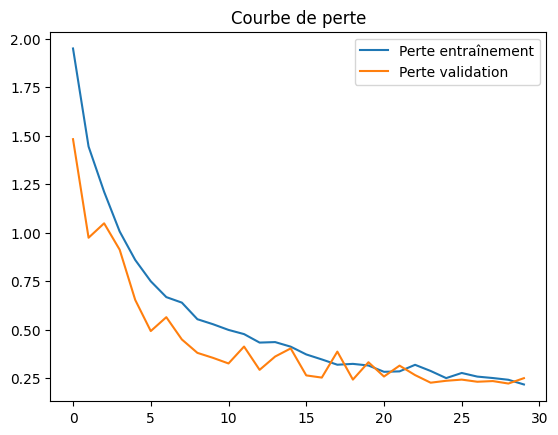

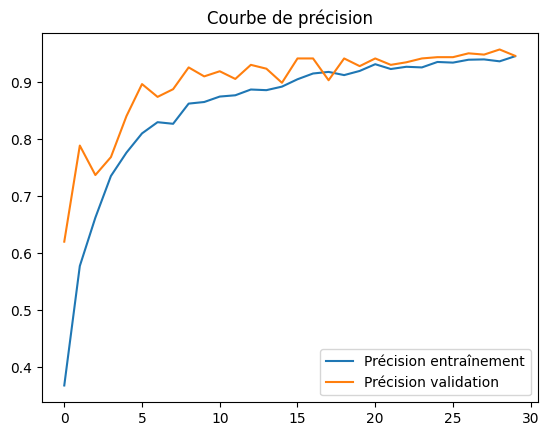

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9391 - loss: 0.2754
Perte sur le jeu de test : 0.2502
Précision sur le jeu de test : 0.9461


In [ ]:

# Courbes de perte et précision
plt.plot(history.history['loss'], label='Perte entraînement')
plt.plot(history.history['val_loss'], label='Perte validation')
plt.legend()
plt.title('Courbe de perte')
plt.show()

plt.plot(history.history['accuracy'], label='Précision entraînement')
plt.plot(history.history['val_accuracy'], label='Précision validation')
plt.legend()
plt.title('Courbe de précision')
plt.show()

# Évaluation finale
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=1)
print(f"Perte sur le jeu de test : {test_loss:.4f}")
print(f"Précision sur le jeu de test : {test_accuracy:.4f}")


In [ ]:
# Évaluation du modèle sur le jeu de test
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=1)

# Afficher les résultats
print(f"Perte sur le jeu de test : {test_loss:.4f}")
print(f"Précision sur le jeu de test : {test_accuracy:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9391 - loss: 0.2754
Perte sur le jeu de test : 0.2502
Précision sur le jeu de test : 0.9461


In [ ]:
# Prédiction sur l'ensemble de test
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes prédites

# Calculer le nombre de prédictions correctes
correct_predictions = np.sum(y_pred_classes == y_test)
incorrect_predictions = len(y_test) - correct_predictions

# Affichage des résultats
print(f"Nombre de prédictions correctes : {correct_predictions}")
print(f"Nombre d'erreurs : {incorrect_predictions}")
print(f"Taux de précision : {correct_predictions / len(y_test) * 100:.2f}%")


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step
Nombre de prédictions correctes : 421
Nombre d'erreurs : 24
Taux de précision : 94.61%


In [ ]:
# Textes pour les tests
nouveaux_textes = [
    "Une nouvelle loi a été votée pour réduire les émissions de carbone et combattre le réchauffement climatique.",
    "Découverte scientifique majeure: des chercheurs ont identifié une nouvelle sous-particule quantique.",
    "Le festival international du film débute cette semaine avec des films provenant de plus de 30 pays.",
    "Une étude révèle que l'exercice régulier peut améliorer significativement la santé mentale.",
    "Les marchés financiers ont connu une volatilité exceptionnelle suite à des changements dans les politiques monétaires."
]

# Nettoyage, tokenisation et padding des nouveaux textes
nouveaux_textes_clean = [clean_text(text) for text in nouveaux_textes]
nouveaux_textes_seq = tokenizer.texts_to_sequences(nouveaux_textes_clean)
nouveaux_textes_padded = pad_sequences(nouveaux_textes_seq, maxlen=max_len, padding='post')

# Prédiction et affichage des probabilités
predictions = model.predict(nouveaux_textes_padded)
predicted_classes = np.argmax(predictions, axis=1)
predicted_probabilities = np.max(predictions, axis=1)  # Obtenir la probabilité de la classe prédite

# Affichage des résultats avec descriptions et probabilités
for i, texte in enumerate(nouveaux_textes):
    print(f"Texte: {texte}")
    print(f"Classe prédite: {class_descriptions.get(predicted_classes[i], 'Classe non identifiée')}")
    print(f"Probabilité: {predicted_probabilities[i] * 100:.2f}%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Texte: Une nouvelle loi a été votée pour réduire les émissions de carbone et combattre le réchauffement climatique.
Classe prédite: Économie et travail
Probabilité: 80.53%
Texte: Découverte scientifique majeure: des chercheurs ont identifié une nouvelle sous-particule quantique.
Classe prédite: Sport et personnalités publiques
Probabilité: 99.78%
Texte: Le festival international du film débute cette semaine avec des films provenant de plus de 30 pays.
Classe prédite: Culture et divertissement
Probabilité: 90.95%
Texte: Une étude révèle que l'exercice régulier peut améliorer significativement la santé mentale.
Classe prédite: Sport et personnalités publiques
Probabilité: 99.78%
Texte: Les marchés financiers ont connu une volatilité exceptionnelle suite à des changements dans les politiques monétaires.
Classe prédite: Culture et divertissement
Probabilité: 90.88%
